#### Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import pandas as pd
import matplotlib.pyplot as plt
import time
import statistics
from pathlib import Path

from pipeline import process_image, get_image_paths

### Konfiguration
Hinweis: Bitte an eigenes lokales Set-Up anpassen
(Laptop 1 = Maxim, Laptop 2 = Ella, Laptop 3 = Jordan)

In [2]:
LAPTOP_ID = 1

# IMG_SIZE = (512, 512)
RUNS = 10

NIH_DIR = "../data/nih_chest_xray"
KAGGLE_DIR = "../data/kaggle_pneumonia"

RESULTS_DIR = f"results/laptop{LAPTOP_ID}"
RESULTS_CSV = f"{RESULTS_DIR}/results_baseline_laptop{LAPTOP_ID}.csv"

IMAGE_COUNTS = [100, 500, 1000, 5000]

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

#### Bilder laden

In [3]:
nih_paths = get_image_paths(NIH_DIR)
kaggle_paths = get_image_paths(KAGGLE_DIR)

print(f"NIH Bilder gefunden:             {len(nih_paths)}")
print(f"Kaggle Pneumonia Bilder gefunden: {len(kaggle_paths)}")

NIH Bilder gefunden:             5000
Kaggle Pneumonia Bilder gefunden: 5000


#### Run

In [4]:
def run_baseline(image_paths):
    t_start = time.perf_counter()

    results = []
    for path in image_paths:
        results.append(process_image(path))

    total_time = time.perf_counter() - t_start
    return total_time, results

#### Benchmark

In [5]:
def benchmark():
    rows = []

    datasets = [
        ("NIH",              nih_paths),
        ("Kaggle Pneumonia", kaggle_paths),
    ]

    for dataset_name, all_paths in datasets:
        print(f"\n=== {dataset_name} ===")

        for n_img in IMAGE_COUNTS:
            subset = all_paths[:n_img]
            if len(subset) < n_img:
                print(f"Nur {len(subset)} Bilder verfügbar, angefragt: {n_img}")
                continue

            runtimes = []

            for _ in range(RUNS):
                runtime, _ = run_baseline(subset)
                runtimes.append(runtime)

            median_runtime = statistics.median(runtimes)
            median_throughput = n_img / median_runtime

            rows.append({
                "Laptop": LAPTOP_ID,
                "Variante": "Baseline",
                "Datensatz": dataset_name,
                "Bilder": n_img,
                "Prozesse": 1,
                "Laufzeit in s": round(median_runtime, 3),
                "Speedup": 1.000,
                "Efficiency": 1.000,
                "Throughput": round(median_throughput, 2),
            })

            print(f"{n_img} Bilder | Median: {median_runtime:.3f}s")

    return pd.DataFrame(rows)


df = benchmark()
df


=== NIH ===
100 Bilder | Median: 0.704s
500 Bilder | Median: 3.645s
1000 Bilder | Median: 7.416s
5000 Bilder | Median: 39.369s

=== Kaggle Pneumonia ===
100 Bilder | Median: 1.020s
500 Bilder | Median: 5.421s
1000 Bilder | Median: 9.865s
5000 Bilder | Median: 28.300s


,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,1,Baseline,NIH,100,1,0.704,1.0,1.0,142.00
1,1,Baseline,NIH,500,1,3.645,1.0,1.0,137.18
2,1,Baseline,NIH,1000,1,7.416,1.0,1.0,134.84
3,1,Baseline,NIH,5000,1,39.369,1.0,1.0,127.00
4,1,Baseline,Kaggle Pneumonia,100,1,1.020,1.0,1.0,98.04
5,1,Baseline,Kaggle Pneumonia,500,1,5.421,1.0,1.0,92.23
6,1,Baseline,Kaggle Pneumonia,1000,1,9.865,1.0,1.0,101.37
7,1,Baseline,Kaggle Pneumonia,5000,1,28.300,1.0,1.0,176.68


#### Speichern

In [6]:
df.to_csv(RESULTS_CSV, index=False)
print(f"Gespeichert: {RESULTS_CSV}")

Gespeichert: results/laptop1/results_baseline_laptop1.csv


#### Plots

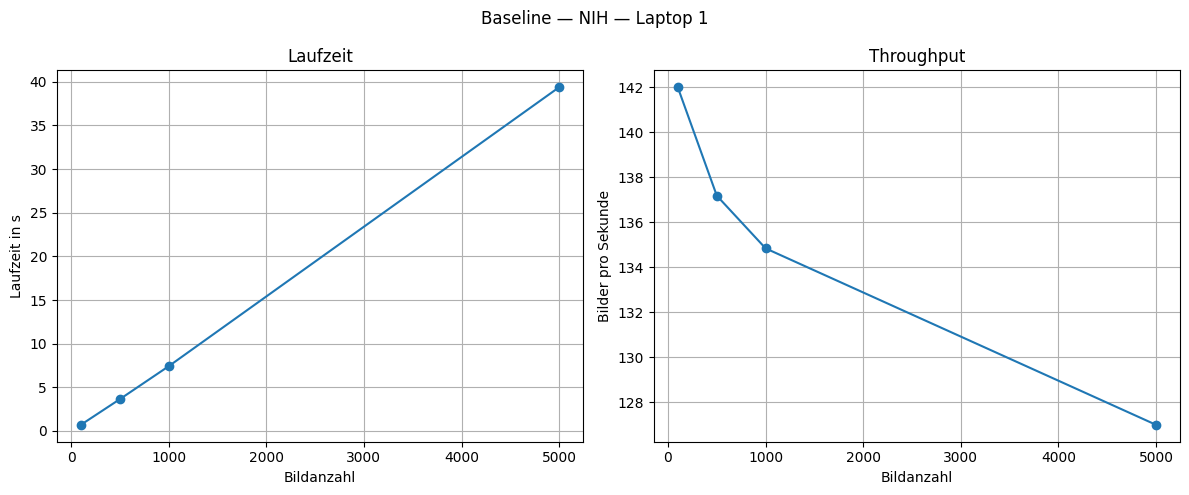

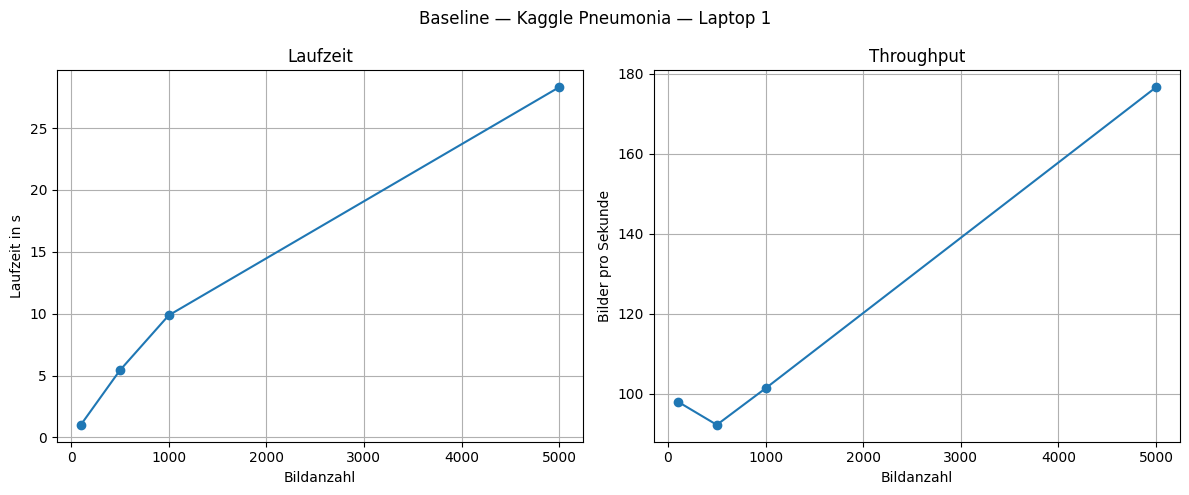

In [7]:
for dataset_name in ["NIH", "Kaggle Pneumonia"]:
    sub = df[df["Datensatz"] == dataset_name]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Baseline — {dataset_name} — Laptop {LAPTOP_ID}")

    axes[0].plot(sub["Bilder"], sub["Laufzeit in s"], marker="o")
    axes[0].set_xlabel("Bildanzahl")
    axes[0].set_ylabel("Laufzeit in s")
    axes[0].set_title("Laufzeit")
    axes[0].grid(True)

    axes[1].plot(sub["Bilder"], sub["Throughput"], marker="o")
    axes[1].set_xlabel("Bildanzahl")
    axes[1].set_ylabel("Bilder pro Sekunde")
    axes[1].set_title("Throughput")
    axes[1].grid(True)

    plt.tight_layout()

    fname = f"{RESULTS_DIR}/baseline_{dataset_name.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
    plt.show()